In [1]:
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load model
model = joblib.load("../models/lgbm_model.pkl")
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('best_lgbm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [3]:
df = pd.read_csv("../../datasets/final_model_data.csv")

In [4]:
target = "diabetes"
X = df.drop(columns=[target])

In [5]:
model.named_steps

{'preprocessor': ColumnTransformer(transformers=[('num', StandardScaler(),
                                  ['age', 'bmi', 'education', 'income',
                                   'gen_health', 'physical_health_days',
                                   'mental_health_days', 'smoked_100_cigarettes',
                                   'drinks_alcohol', 'had_stroke',
                                   'had_heart_attack',
                                   'had_coronary_heart_disease', 'cost_barrier',
                                   'l_checkup', 'has_personal_doctor',
                                   'socioeconomic_tier']),
                                 ('cat', OneHotEncoder(handle_unknown='ignore'),
                                  ['sex', 'marital_status', 'employment_status',
                                   'exercise', 'high_bp'])]),
 'best_lgbm': LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=300,
                n_jobs=-1, random_state=42)}

In [6]:
# extract pipeline components
preprocessor = model.named_steps["preprocessor"]
lgbm = model.named_steps["best_lgbm"]

In [7]:
# transform data
X_transformed = preprocessor.transform(X)

In [8]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['num__age', 'num__bmi', 'num__education', 'num__income',
       'num__gen_health', 'num__physical_health_days',
       'num__mental_health_days', 'num__smoked_100_cigarettes',
       'num__drinks_alcohol', 'num__had_stroke', 'num__had_heart_attack',
       'num__had_coronary_heart_disease', 'num__cost_barrier',
       'num__l_checkup', 'num__has_personal_doctor',
       'num__socioeconomic_tier', 'cat__sex_Female', 'cat__sex_Male',
       'cat__marital_status_Married/Cohabiting',
       'cat__marital_status_Previously Married',
       'cat__marital_status_Single', 'cat__employment_status_Employed',
       'cat__employment_status_Retired',
       'cat__employment_status_Student/Homemaker',
       'cat__employment_status_Unable to work',
       'cat__employment_status_Unemployed', 'cat__exercise_False',
       'cat__exercise_True', 'cat__high_bp_Borderline', 'cat__high_bp_No',
       'cat__high_bp_Yes'], dtype=object)

In [9]:
def clean_feature_name(name):
    # 1. Remove sklearn prefixes
    clean = name.replace('num__', '').replace('cat__', '')
    
    # 2. Specific clinical and professional manual renames
    mapping = {
        'age': 'Age',
        'bmi': 'Body Mass Index (BMI)',
        'education': 'Education Level',
        'income': 'Income Level',
        'gen_health': 'General Health Self-Rating',
        'physical_health_days': 'Physical Health (Recent Bad Days)',
        'mental_health_days': 'Mental Health (Recent Bad Days)',
        'smoked_100_cigarettes': 'Smoked >= 100 Cigarettes Lifetime',
        'drinks_alcohol': 'Alcohol Consumption',
        'had_stroke': 'History of Stroke',
        'had_heart_attack': 'History of Heart Attack',
        'had_coronary_heart_disease': 'History of Coronary Heart Disease',
        'cost_barrier': 'Healthcare Cost Barrier',
        'l_checkup': 'Time Since Last Medical Checkup',
        'has_personal_doctor': 'Has Personal Healthcare Provider',
        'socioeconomic_tier': 'Socioeconomic Tier',
        
        # Categorical break-outs
        'sex_Female': 'Sex: Female',
        'sex_Male': 'Sex: Male',
        'marital_status_Married/Cohabiting': 'Marital Status: Married/Cohabiting',
        'marital_status_Previously Married': 'Marital Status: Previously Married',
        'marital_status_Single': 'Marital Status: Single',
        'employment_status_Employed': 'Employment: Employed',
        'employment_status_Retired': 'Employment: Retired',
        'employment_status_Student/Homemaker': 'Employment: Student/Homemaker',
        'employment_status_Unable to work': 'Employment: Unable to Work',
        'employment_status_Unemployed': 'Employment: Unemployed',
        'exercise_False': 'Physical Exercise: No',
        'exercise_True': 'Physical Exercise: Yes',
        'high_bp_Borderline': 'Blood Pressure: Borderline High',
        'high_bp_No': 'Blood Pressure: Normal/No',
        'high_bp_Yes': 'Blood Pressure: Hypertension/Yes'
    }
    
    return mapping.get(clean, clean)

# Create a clean array and a dictionary for mapping
cleaned_feature_names = np.array([clean_feature_name(name) for name in feature_names])
rename_dict = dict(zip(feature_names, cleaned_feature_names))

In [10]:
cleaned_feature_names

array(['Age', 'Body Mass Index (BMI)', 'Education Level', 'Income Level',
       'General Health Self-Rating', 'Physical Health (Recent Bad Days)',
       'Mental Health (Recent Bad Days)',
       'Smoked >= 100 Cigarettes Lifetime', 'Alcohol Consumption',
       'History of Stroke', 'History of Heart Attack',
       'History of Coronary Heart Disease', 'Healthcare Cost Barrier',
       'Time Since Last Medical Checkup',
       'Has Personal Healthcare Provider', 'Socioeconomic Tier',
       'Sex: Female', 'Sex: Male', 'Marital Status: Married/Cohabiting',
       'Marital Status: Previously Married', 'Marital Status: Single',
       'Employment: Employed', 'Employment: Retired',
       'Employment: Student/Homemaker', 'Employment: Unable to Work',
       'Employment: Unemployed', 'Physical Exercise: No',
       'Physical Exercise: Yes', 'Blood Pressure: Borderline High',
       'Blood Pressure: Normal/No', 'Blood Pressure: Hypertension/Yes'],
      dtype='<U34')

In [11]:
# SHAP values
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_transformed)

# handle binary classification output format
if isinstance(shap_values, list):
    shap_values = shap_values[1]

/home/maradeben/dev/wotosuga-core/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [12]:
joblib.dump(explainer, "../models/shap_explainer.pkl")

['../models/shap_explainer.pkl']

In [13]:
explainer.feature_names = list(cleaned_feature_names)

In [14]:
# feature importance table
importance = np.abs(shap_values).mean(axis=0)
importance_df = (
    pd.DataFrame({
        "feature": cleaned_feature_names,
        "importance": importance
    })
    .sort_values("importance", ascending=False)
)

print("\nTop 20 Features")
print(importance_df.head(20))

importance_df.to_csv(
    "shap_feature_importance.csv",
    index=False
)


Top 20 Features
                              feature  importance
0                                 Age    0.537610
4          General Health Self-Rating    0.487176
1               Body Mass Index (BMI)    0.368083
29          Blood Pressure: Normal/No    0.313661
13    Time Since Last Medical Checkup    0.251758
30   Blood Pressure: Hypertension/Yes    0.208851
8                 Alcohol Consumption    0.190911
16                        Sex: Female    0.125686
14   Has Personal Healthcare Provider    0.101626
3                        Income Level    0.096292
26              Physical Exercise: No    0.055172
2                     Education Level    0.043935
12            Healthcare Cost Barrier    0.030785
21               Employment: Employed    0.030284
10            History of Heart Attack    0.030250
11  History of Coronary Heart Disease    0.026146
7   Smoked >= 100 Cigarettes Lifetime    0.020166
9                   History of Stroke    0.019745
6     Mental Health (Recent Bad D

In [15]:
importance_df.to_csv(
    "shap_feature_importance.csv",
    index=False
)

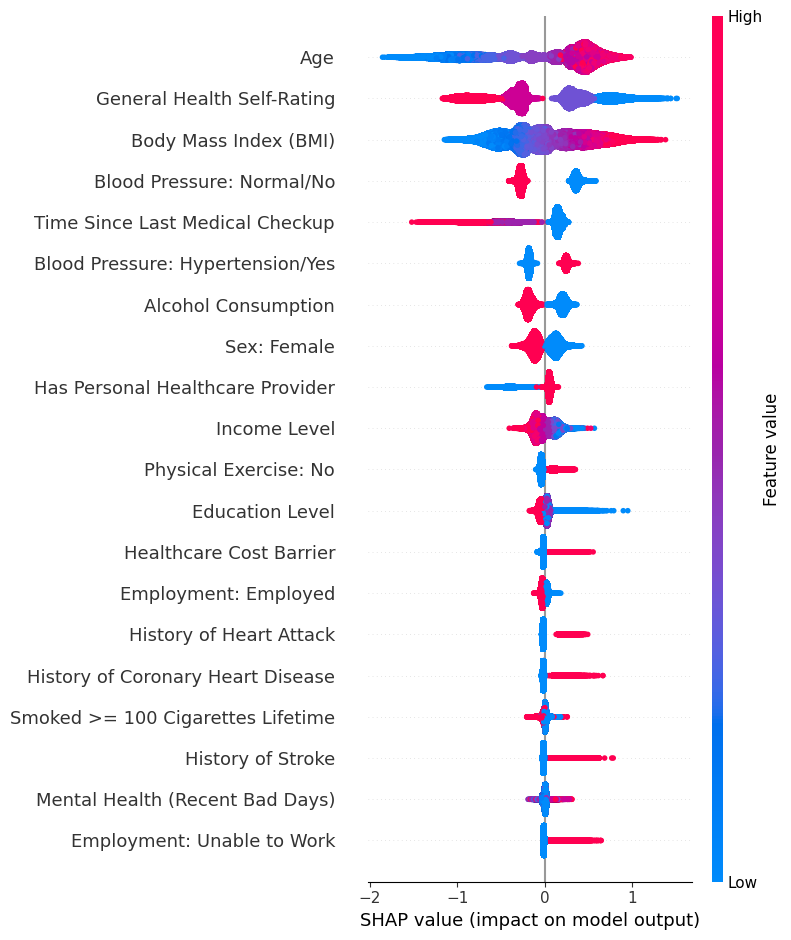

In [16]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=cleaned_feature_names,
    show=False
)

plt.tight_layout()
plt.savefig(
    "shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

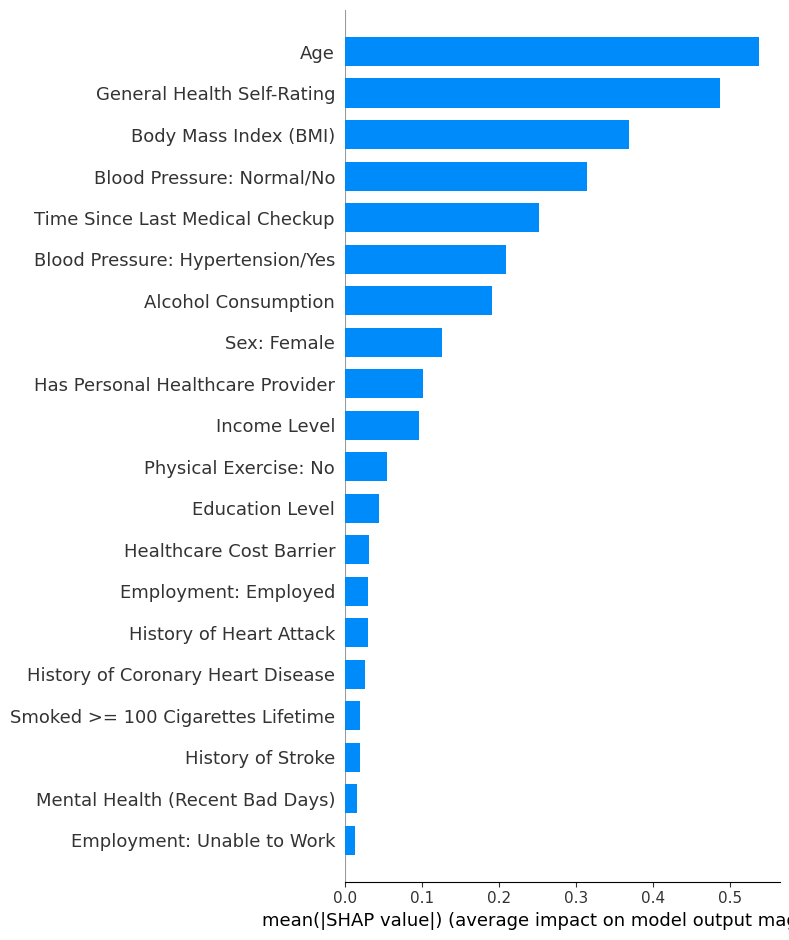

In [17]:
# SHAP bar plot
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=cleaned_feature_names,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig(
    "shap_importance_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


['num__age' 'num__bmi' 'num__education' 'num__income' 'num__gen_health'
 'num__physical_health_days' 'num__mental_health_days'
 'num__smoked_100_cigarettes' 'num__drinks_alcohol' 'num__had_stroke'
 'num__had_heart_attack' 'num__had_coronary_heart_disease'
 'num__cost_barrier' 'num__l_checkup' 'num__has_personal_doctor'
 'num__socioeconomic_tier' 'cat__sex_Female' 'cat__sex_Male'
 'cat__marital_status_Married/Cohabiting'
 'cat__marital_status_Previously Married' 'cat__marital_status_Single'
 'cat__employment_status_Employed' 'cat__employment_status_Retired'
 'cat__employment_status_Student/Homemaker'
 'cat__employment_status_Unable to work'
 'cat__employment_status_Unemployed' 'cat__exercise_False'
 'cat__exercise_True' 'cat__high_bp_Borderline' 'cat__high_bp_No'
 'cat__high_bp_Yes']


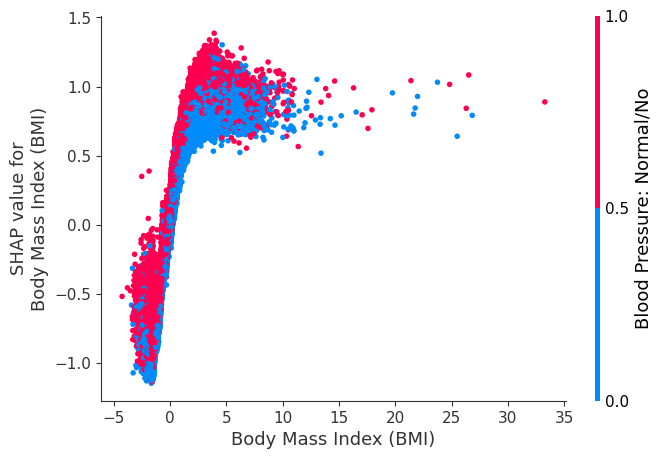

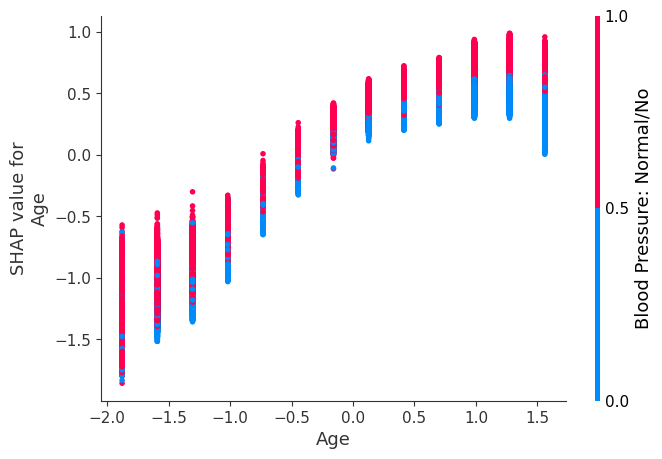

In [21]:
# Optional: Dependence Plots
print(feature_names)

shap.dependence_plot(
    "Body Mass Index (BMI)",
    shap_values,
    X_transformed,
    feature_names=cleaned_feature_names
)

shap.dependence_plot(
    "Age",
    shap_values,
    X_transformed,
    feature_names=cleaned_feature_names
)

In [22]:
# check and compare model coefs for LogReg
logreg = joblib.load("../models/logreg_model.pkl")
print(logreg.named_steps)
logreg

{'preprocessor': ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'bmi', 'education', 'income',
                                  'gen_health', 'physical_health_days',
                                  'mental_health_days', 'smoked_100_cigarettes',
                                  'drinks_alcohol', 'had_stroke',
                                  'had_heart_attack',
                                  'had_coronary_heart_disease', 'cost_barrier',
                                  'l_checkup', 'has_personal_doctor',
                                  'socioeconomic_tier']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['sex', 'marital_status', 'employment_status',
                                  'exercise', 'high_bp'])]), 'lr': LogisticRegression(C=0.01, class_weight='balanced', random_state=42)}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [23]:
logreg_model = logreg.named_steps["lr"] #xgb here is a misnomer
logreg_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term

In [24]:
coef_df = pd.DataFrame({
    "feature": cleaned_feature_names,
    "coef": logreg_model.coef_[0]
}).sort_values("coef", key=abs, ascending=False)
coef_df

,feature,coef
0,Age,0.568202
4,General Health Self-Rating,-0.510236
1,Body Mass Index (BMI),0.455182
29,Blood Pressure: Normal/No,-0.448243
13,Time Since Last Medical Checkup,-0.357720
30,Blood Pressure: Hypertension/Yes,0.279705
16,Sex: Female,-0.225123
8,Alcohol Consumption,-0.202843
23,Employment: Student/Homemaker,-0.152132
14,Has Personal Healthcare Provider,0.143906


In [25]:
coef_df.to_csv(
    "lr_coef.csv",
    index=False
)

This seems to be fairly consistent with the SHAP explainer as well.